In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load dataset
df = pd.read_csv('exoTrain.csv')


In [4]:
#shape of training df
df.shape

(5087, 3198)

In [5]:
#display the rows with null values in df
df[df.isnull().any(axis = 1)]


,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197


<Axes: >

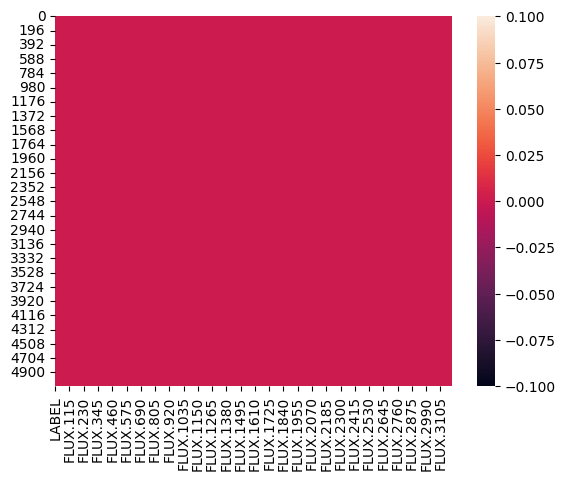

In [6]:
#display null values in train df
import seaborn as sns
sns.heatmap(df.isnull())

In [7]:
#check how many labels are present
df['LABEL'].unique()

array([2, 1], dtype=int64)

In [8]:
#Replacing labels
df = df.replace({'LABEL' : {2 : 1, 1 : 0}})
df.LABEL.unique()


array([1, 0], dtype=int64)

In [9]:
#extract the index for the stars labelled as 2
list(df[df['LABEL'] == 1].index)

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36]

[Text(0, 0, '5050'), Text(0, 0, '37')]

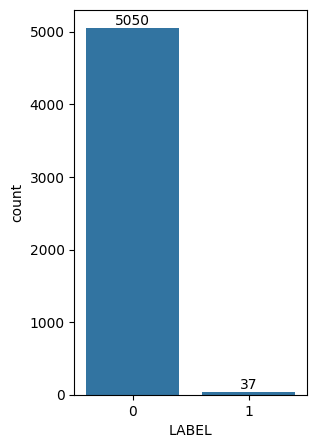

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize = (3, 5))
ax = sns.countplot(x = 'LABEL', data = df)
ax.bar_label(ax.containers [0])


In [11]:
flux_cols = df.drop(['LABEL'], axis = 1)
flux_cols


,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,FLUX.10,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,-160.17,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,-73.38,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,484.39,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,323.33,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,-970.88,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5082,-91.91,-92.97,-78.76,-97.33,-68.00,-68.24,-75.48,-49.25,-30.92,-11.88,...,139.95,147.26,156.95,155.64,156.36,151.75,-24.45,-17.00,3.23,19.28
5083,989.75,891.01,908.53,851.83,755.11,615.78,595.77,458.87,492.84,384.34,...,-26.50,-4.84,-76.30,-37.84,-153.83,-136.16,38.03,100.28,-45.64,35.58
5084,273.39,278.00,261.73,236.99,280.73,264.90,252.92,254.88,237.60,238.51,...,-26.82,-53.89,-48.71,30.99,15.96,-3.47,65.73,88.42,79.07,79.43
5085,3.82,2.09,-3.29,-2.88,1.66,-0.75,3.85,-0.03,3.28,6.29,...,10.86,-3.23,-5.10,-4.61,-9.82,-1.50,-4.65,-14.55,-6.41,-2.55


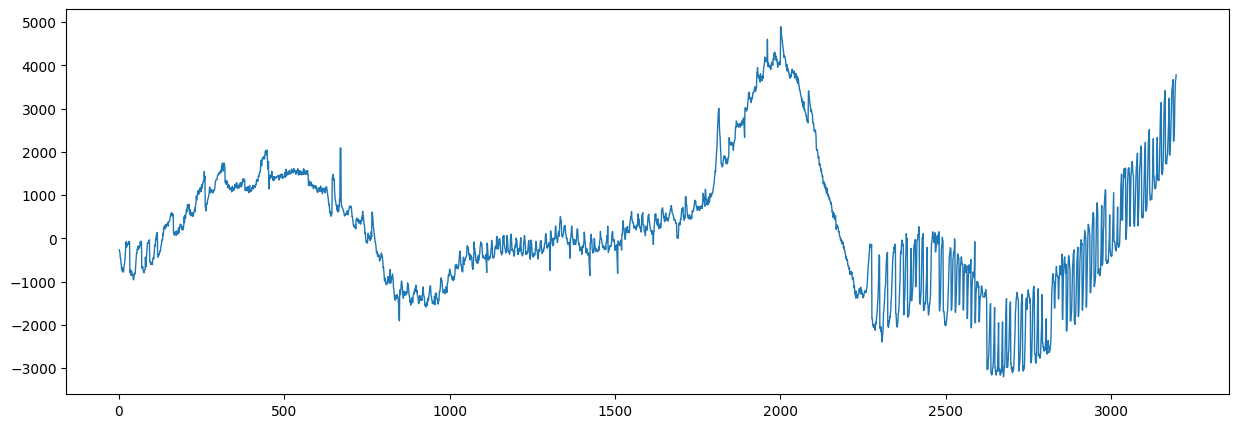

In [12]:
#plot a random star from the plot df
time = range(1, 3198)
flux_val = flux_cols.iloc[9, :].values
plt.figure(figsize = (15, 5))
plt.plot(time, flux_val, linewidth = 1)

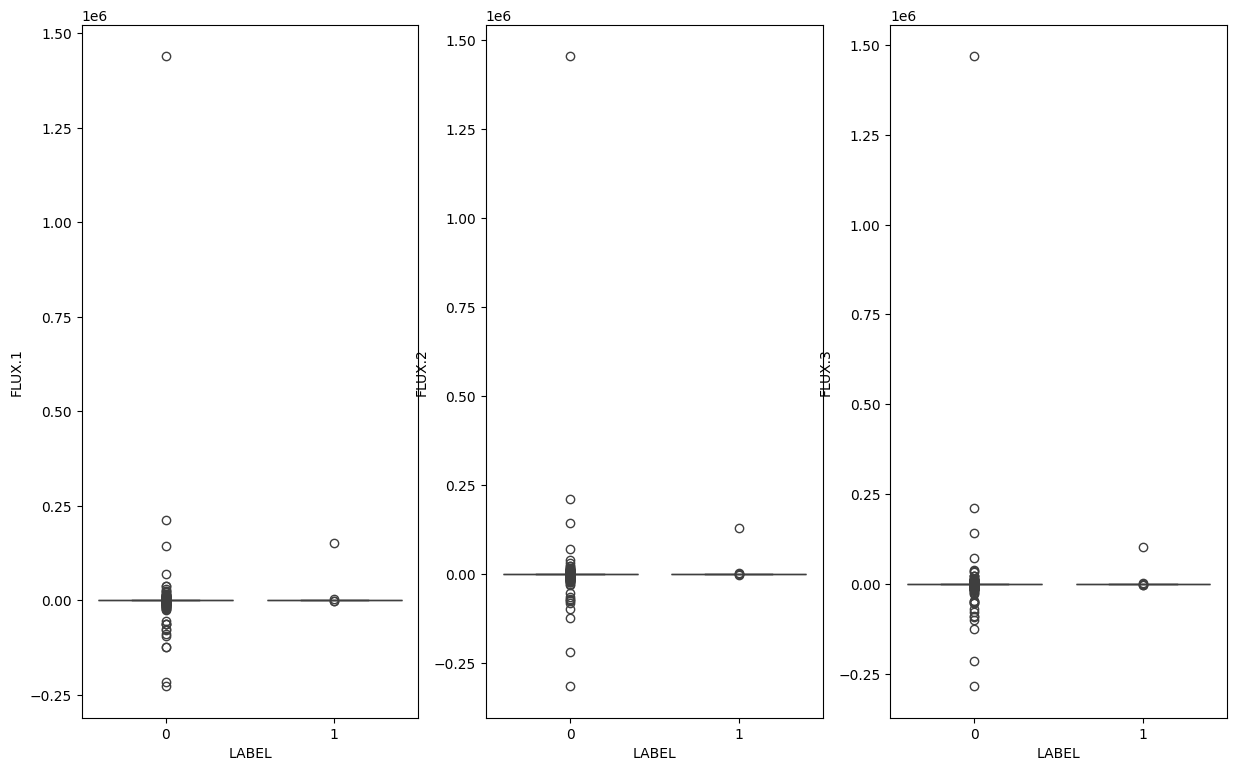

In [13]:
plt.figure(figsize= (20, 9))
for i in range(1,4):
    plt.subplot(1, 4, i)
    sns.boxplot(data = df, x = 'LABEL', y = 'FLUX.' +str(i))


In [14]:
#Dropping outliers
df.drop(df[df['FLUX.2'] > 0.25e6].index, axis = 0, inplace= True )


<Axes: xlabel='LABEL', ylabel='FLUX.925'>

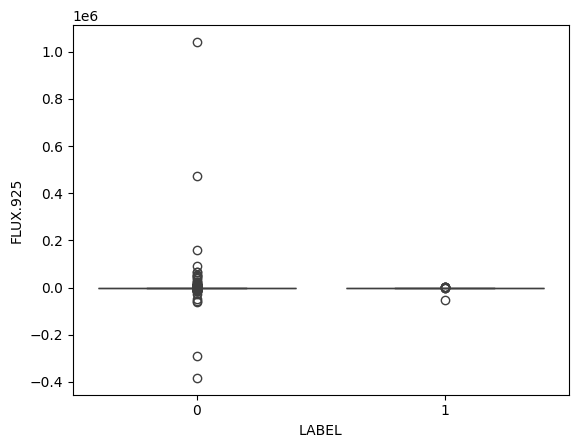

In [15]:
sns.boxplot(data = df, x = 'LABEL', y = 'FLUX.' +str(np.random.randint(1000)))

In [16]:
# Splitting features and target
X = df.select_dtypes(include=['number']).drop(columns=['LABEL'])  
y = df['LABEL']
print("Feature set shape (dynamic):", X.shape)

Feature set shape (dynamic): (5086, 3197)


In [17]:
# Train-test split (80-20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
print("Unique values in y_train before SMOTE:", set(y_train))

# Apply SMOTE only if there are at least 2 classes in y_train
if len(set(y_train)) > 1:
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    print("After SMOTE:", dict(zip(*np.unique(y_train_sm, return_counts=True))))
else:
    print("SMOTE cannot be applied as y_train has only one class")
    X_train_sm, y_train_sm = X_train, y_train


Unique values in y_train before SMOTE: {0, 1}
After SMOTE: {0: 4038, 1: 4038}


In [19]:
from collections import Counter
print("Class distribution after SMOTE:", Counter(y_train_sm))


Class distribution after SMOTE: Counter({0: 4038, 1: 4038})


In [20]:
# Function to train and evaluate models
def train_evaluate_model(model, model_name):
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    print(f"\nModel: {model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

In [21]:
# Standardizing features
scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

In [22]:
X_train_sm, X_test, y_train_sm, y_test = train_test_split(X_train_sm, y_train_sm, test_size=0.2, random_state=42, stratify=y_train_sm)


In [23]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight = 'balanced', random_state=42)
rf.fit(X_train_sm,y_train_sm)
train_evaluate_model(rf, "Random Forest")


Model: Random Forest
Accuracy: 0.9993811881188119
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       808
           1       1.00      1.00      1.00       808

    accuracy                           1.00      1616
   macro avg       1.00      1.00      1.00      1616
weighted avg       1.00      1.00      1.00      1616



In [24]:
import pickle

# Save model
with open('randomForest.pkl', 'wb') as file:
    pickle.dump(rf, file)

print("Model saved successfully!") 

# Load the saved model
with open('randomForest.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Now make predictions
y_pred = loaded_model.predict(X_test)

# Check accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Loaded Model Accuracy:", accuracy)


Model saved successfully!
Loaded Model Accuracy: 0.9993811881188119


In [25]:
# XGBoost
xgb = XGBClassifier(scale_pos_weight=(sum(y_train_sm == 0) / sum(y_train_sm == 1)),use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_sm, y_train_sm)
train_evaluate_model(xgb, "XGBoost")


Model: XGBoost
Accuracy: 0.9987623762376238
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       808
           1       1.00      1.00      1.00       808

    accuracy                           1.00      1616
   macro avg       1.00      1.00      1.00      1616
weighted avg       1.00      1.00      1.00      1616



In [26]:
import pickle

# Save model
with open('xgboost.pkl', 'wb') as file:
    pickle.dump(xgb, file)

print("Model saved successfully!") 

# Load the saved model
with open('xgboost.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Now make predictions
y_pred = loaded_model.predict(X_test)

# Check accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Loaded Model Accuracy:", accuracy) 


Model saved successfully!
Loaded Model Accuracy: 0.9987623762376238


In [27]:
y_pred_probs = rf.predict_proba(X_test)[:, 1]  # Probability for class 1
y_pred = (y_pred_probs > 0.0001).astype(int)   # Adjust threshold


In [28]:
# Support Vector Machine (SVM)
svm = SVC(kernel='linear', probability=True)
train_evaluate_model(svm, "Support Vector Machine")



Model: Support Vector Machine
Accuracy: 0.9783415841584159
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98       808
           1       0.96      1.00      0.98       808

    accuracy                           0.98      1616
   macro avg       0.98      0.98      0.98      1616
weighted avg       0.98      0.98      0.98      1616



In [29]:
import pickle

# Save model
with open('svm.pkl', 'wb') as file:
    pickle.dump(svm, file)

print("Model saved successfully!") 

# Load the saved model
with open('svm.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Now make predictions
y_pred = loaded_model.predict(X_test)

# Check accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Loaded Model Accuracy:", accuracy)


Model saved successfully!
Loaded Model Accuracy: 0.9783415841584159


In [30]:
y_pred_probs = svm.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_pred_probs > 0.1).astype(int)


In [31]:
y_pred = svm.predict(X_test)  
import pandas as pd
df_results = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(df_results.sample(10))  # Randomly check 10 predictions


      Actual  Predicted
4854       1          1
5676       1          1
2230       0          0
2924       0          0
4928       1          1
3072       0          0
393        0          0
6158       1          1
3140       0          0
6724       1          1


In [32]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[773  35]
 [  0 808]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       808
           1       0.96      1.00      0.98       808

    accuracy                           0.98      1616
   macro avg       0.98      0.98      0.98      1616
weighted avg       0.98      0.98      0.98      1616



In [33]:
y_pred_probs = xgb.predict_proba(X_test)[:, 1]
print(y_pred_probs[:20])


[5.1989011e-03 9.9991214e-01 9.9817109e-01 9.9971348e-01 2.2714337e-05
 3.3778400e-05 2.0947425e-04 9.9990749e-01 9.9977142e-01 4.3631982e-04
 9.9991548e-01 2.6245672e-05 1.6285130e-05 6.0086843e-04 2.2966694e-04
 2.4068868e-05 9.9802750e-01 1.4267505e-05 9.9969220e-01 1.1974986e-02]


In [34]:
y_pred_probs = xgb.predict_proba(X_test)[:, 1]  # Class 1 ki probability lo
print(y_pred_probs[:10])  # Pehli 10 probability values print karo


[5.1989011e-03 9.9991214e-01 9.9817109e-01 9.9971348e-01 2.2714337e-05
 3.3778400e-05 2.0947425e-04 9.9990749e-01 9.9977142e-01 4.3631982e-04]


In [35]:
import joblib
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']